# A/B Testing Project


**Data columns (source file):**

`user_id` | `timestamp` | `group` | `landing_page` | `converted`


## 1.0 Problem Definition & Business Context

### 1.1 Business Question
> **Does the newly designed landing page result in a higher conversion rate compared to the existing(old) landing page?**

### 1.2 Hypothesis Formulation

- **Null Hypothesis (H₀):**
  The conversion rate of the new landing page is equal to the conversion rate of the old landing page.
- **Alternative Hypothesis (H₁):**
  The conversion rate of the new landing page is different from the conversion rate of the old landing page.


### 1.3 Success Metric

- **Primary metric:** Conversion Rate
- **Secondary checks:** Balanced sample sizes across groups and validation of correct user exposure to each variant

## 2.0 Data Understanding

### 2.1 Schema Validation
Before analysis, we verify that all expected columns are present and semantically correct:
- `user_id` → unique identifier for each user
- `group` → experimental assignment (control or treatment)
- `landing_page` → page variant shown to the user (old or new)
- `converted` → binary outcome  indicating whether a conversion occured (0=no, 1=yes)

### 2.2 Basic Inspection
A preliminary data quality check is performed to identify any obvious issues before deeper analysis, including:
- Dataset dimensions (rows and columns)
- Data types non-null counts
- Missing values
- Distribution of values across key columns

In [1]:
# 2.0 Import core analysis libraries used in this notebook.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# 2.1 Load the raw A/B dataset and preview the first few rows
df = pd.read_csv('ab_data.csv')
df.head()

ERROR! Session/line number was not unique in database. History logging moved to new session 4


,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


In [3]:
# 2.2 Check the dataset dimensions (rows, columns)
df.shape

(294478, 5)

In [4]:
# Inspect column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294478 entries, 0 to 294477
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   user_id       294478 non-null  int64 
 1   timestamp     294478 non-null  object
 2   group         294478 non-null  object
 3   landing_page  294478 non-null  object
 4   converted     294478 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.2+ MB


In [5]:
# Convert timestamp column to datetime for time-based validation
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['timestamp'].dtype


dtype('<M8[ns]')

In [6]:
# Summarize missing values per column
df.isnull().sum()


user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

In [7]:
# Review value distributions for each column
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts())



user_id:
user_id
805339    2
754884    2
722274    2
783176    2
898232    2
         ..
642985    1
771499    1
923606    1
712675    1
715931    1
Name: count, Length: 290584, dtype: int64

timestamp:
timestamp
2017-01-21 22:11:48.556739    1
2017-01-14 00:19:20.419940    1
2017-01-10 04:54:54.307909    1
2017-01-04 19:15:59.966448    1
2017-01-10 04:13:56.984483    1
                             ..
2017-01-22 23:52:05.547822    1
2017-01-03 01:52:22.432039    1
2017-01-03 19:38:12.778963    1
2017-01-17 02:21:47.173042    1
2017-01-16 12:40:24.467417    1
Name: count, Length: 294478, dtype: int64

group:
group
treatment    147276
control      147202
Name: count, dtype: int64

landing_page:
landing_page
old_page    147239
new_page    147239
Name: count, dtype: int64

converted:
converted
0    259241
1     35237
Name: count, dtype: int64


In [8]:
# 2.3 Validate schema expectations and allowed value domains
expected_columns = {"user_id", "timestamp", "group", "landing_page", "converted"}
actual_columns = set(df.columns)

missing_columns = expected_columns - actual_columns
extra_columns = actual_columns - expected_columns

print("Missing columns:", missing_columns or "None")
print("Unexpected columns:", extra_columns or "None")

print("Group values:", sorted(df["group"].unique()))
print("Landing page values:", sorted(df["landing_page"].unique()))
print("Converted values:", sorted(df["converted"].unique()))


Missing columns: None
Unexpected columns: None
Group values: ['control', 'treatment']
Landing page values: ['new_page', 'old_page']
Converted values: [np.int64(0), np.int64(1)]


## 3.0 Data Cleaning & Validation (Critical for A/B Tests)

### 3.1 Remove Duplicate Users
To preserve the independence assumption of the experiment, each user must appear only once in the dataset.
- If a user appears multiple times, only the first exposure is retained
- All subsequent duplicate records are removed

### 3.2 Group–Page Consistency Check
Users must be exposed to the correct landing page based on their experimental assignment.

The following cases violate experimental integrity and are removed:
- Control group users shown the new landing page
- Treatment group users shown the old landing page
> Such mismatches break randomization and can bias the results.

### 3.3 Post-Cleaning Sanity Check
After cleaning, the dataset is validated to ensure:
- Control group users are shown only the old page
- Treatment group users are shown only the new page
- Group sizes remain reasonably balanced

In [9]:
# 3.1 Count duplicate users before deduplication
df['user_id'].duplicated().value_counts()


user_id
False    290584
True       3894
Name: count, dtype: int64

In [10]:
# Remove duplicate users, keeping their first exposure
df = df.drop_duplicates(subset='user_id', keep='first')


In [11]:
# Verify that duplicates have been removed
df['user_id'].duplicated().value_counts()


user_id
False    290584
Name: count, dtype: int64

In [12]:
# 3.2 Identify group–page mismatches
mismatch_mask = (
    ((df["group"] == "control") & (df["landing_page"] == "new_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "old_page"))
)

print("Number of mismatched rows:", mismatch_mask.sum())


Number of mismatched rows: 2044


In [13]:
# Inspect group vs landing page combinations
pd.crosstab(df["group"], df["landing_page"])


landing_page,new_page,old_page
group,,
control,1006,144226
treatment,144314,1038


In [14]:
# Retain only valid group–page pairings
valid_mask = (
    ((df["group"] == "control") & (df["landing_page"] == "old_page")) |
    ((df["group"] == "treatment") & (df["landing_page"] == "new_page"))
)

df_clean = df.loc[valid_mask].copy()
print("Rows retained after cleaning:", len(df_clean))


Rows retained after cleaning: 288540


In [15]:
# 3.3 Post-cleaning sanity checks
print(pd.crosstab(df_clean["group"], df_clean["landing_page"]))
print("\nGroup sizes:\n", df_clean["group"].value_counts())


landing_page  new_page  old_page
group                           
control              0    144226
treatment       144314         0

Group sizes:
 group
treatment    144314
control      144226
Name: count, dtype: int64


## 4.0 Exploratory Data Analysis (EDA)

### 4.1 Overall Conversion Rate
As an initial baseline, the overall conversion rate is calculated by dividing the total number of conversions by the total number of users in the cleaned dataset.

### 4.2 Group-Wise Metrics
To compare experimental outcomes, the following metrics are computed separately for the control and treatment groups:
- Total number of users
- Total number of conversions
- Conversion rate

These metrics provide an early indication of potential performance differences between the two landing pages.

### 4.3 Visual Exploration
Simple visualizations are used to support interpretation and communication:
- A bar chart comparing conversion rates across groups
- A bar chart showing user counts per group

> Visual summaries are especially useful when presenting results to non-technical stakeholders.

In [16]:
# 4.1 Compute overall conversion rate (%) using cleaned data
conversion_rate = df_clean["converted"].mean() * 100
conversion_rate


np.float64(11.950856033825467)

In [17]:
# Count total users per group
df_clean.groupby("group")["user_id"].count()


group
control      144226
treatment    144314
Name: user_id, dtype: int64

In [18]:
# 4.2 Count total conversions per group
df_clean.groupby("group")["converted"].sum()


group
control      17349
treatment    17134
Name: converted, dtype: int64

In [19]:
# 4.2 Compute conversion rate (%) per group
df_clean.groupby("group")["converted"].mean() * 100


group
control      12.029038
treatment    11.872722
Name: converted, dtype: float64

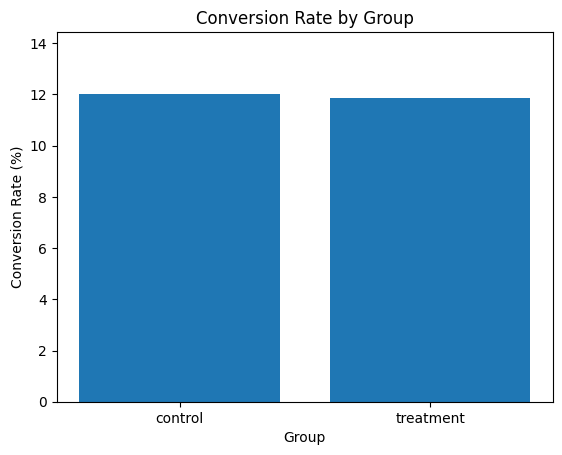

In [20]:
# 4.3 Visualize conversion rate by group
conversion_by_group = df_clean.groupby("group")["converted"].mean() * 100

plt.bar(conversion_by_group.index, conversion_by_group.values)
plt.xlabel("Group")
plt.ylabel("Conversion Rate (%)")
plt.title("Conversion Rate by Group")
plt.ylim(0, max(conversion_by_group.values) * 1.2)
plt.show()


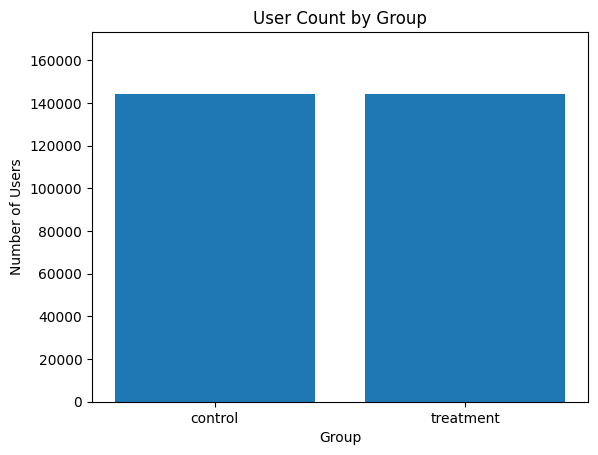

In [21]:
# 4.3 Visualize user counts by group
user_counts = df_clean.groupby("group")["user_id"].count()

plt.bar(user_counts.index, user_counts.values)
plt.xlabel("Group")
plt.ylabel("Number of Users")
plt.title("User Count by Group")
plt.ylim(0, max(user_counts.values) * 1.2)
plt.show()


## 5.0 Experimental Design Validation
Before conducting statistical tests, the experimental setup is validated to ensure that core A/B testing assumptions are satisfied.

### 5.1 Randomization Check
To confirm proper random assignment, we verify that:
- Users are distributed roughly evenly between control and treatment groups
- No extreme imbalance exists (defined here as greater than a 55/45 split)

### 5.2 Independence Assumption
The independence assumption requires that:
- Each user appears only once in the dataset
- Users are exposed to a single variant only

### 5.3 Sample Size Adequacy
To assess whether the experiment is sufficiently powered, we estimate:
- The minimum detectable effect (MDE) given the current sample size
- Whether the dataset can detect a practically meaningful lift (e.g., 1 percentage point)

In [22]:
# 5.1 Randomization check: group balance
counts = df_clean["group"].value_counts()
proportions = counts / counts.sum()
imbalance_flag = proportions.max() > 0.55

print("Group counts:\n", counts)
print("\nGroup proportions:\n", proportions.round(4))
print("\nImbalance flag (>55/45):", imbalance_flag)


Group counts:
 group
treatment    144314
control      144226
Name: count, dtype: int64

Group proportions:
 group
treatment    0.5002
control      0.4998
Name: count, dtype: float64

Imbalance flag (>55/45): False


**Interpretation:**
Balanced group sizes support the validity of randomization and reduce bias in treatment comparisons.

In [23]:
# 5.2 Independence assumption: each user appears once
duplicate_users = df_clean["user_id"].duplicated().sum()
print("Duplicate user_id count (clean data):", duplicate_users)
print("Carryover effects: assumed absent (not observable in this dataset)")


Duplicate user_id count (clean data): 0
Carryover effects: assumed absent (not observable in this dataset)


**Interpretation:**
With duplicate users removed earlier, the independence assumption is satisfied.

In [24]:
# 5.3 Sample size adequacy: MDE based on current sample size
from statistics import NormalDist

alpha = 0.05
power = 0.80

z_alpha = NormalDist().inv_cdf(1 - alpha / 2)
z_beta = NormalDist().inv_cdf(power)

p0 = df_clean.loc[df_clean["group"] == "control", "converted"].mean()
n_per_group = counts.min()

# Approximate absolute MDE for a two-proportion z-test
mde = ((z_alpha + z_beta) * (2 * p0 * (1 - p0)) ** 0.5) / (n_per_group ** 0.5)

print("Baseline conversion (control):", round(p0, 4))
print("n per group (min):", int(n_per_group))
print("Approx MDE (absolute):", round(mde, 4), f"(~{round(mde * 100, 2)} pp)")


Baseline conversion (control): 0.1203
n per group (min): 144226
Approx MDE (absolute): 0.0034 (~0.34 pp)


In [25]:
# Required sample size for a target MDE (example: 1 percentage point)
target_mde = 0.01

required_n = (
    2 * p0 * (1 - p0) * (z_alpha + z_beta) ** 2 / (target_mde ** 2)
)

print("Required n per group for 1.0 pp MDE:", int(required_n))
print("Meets 1.0 pp MDE:", n_per_group >= required_n)


Required n per group for 1.0 pp MDE: 16611
Meets 1.0 pp MDE: True


**Interpretation:**
This analysis clarifies whether the experiment is capable of detecting small but meaningful changes in conversion rate, helping distinguish between no effect and insufficient power.

## 6.0 Statistical Hypothesis Testing
After validating the experimental design, we formally test whether the observed difference in conversion rates between the two groups is statistically significant.

### 6.1 Test Selection
Given that:
- The outcome variable (`converted`) is binary
- The control and treatment groups are independent
> A two-proportion Z-test is used to compare conversion rates.

### 6.2 Significance Level
The significance level is set to the conventional threshold:
- **α = 0.05** (standard)

### 6.3 Test Execution
The following quantities are computed:
- Conversion rate for the control group
- Conversion rate for the treatment group
- Z-score
-Two-tailed p-value

In [26]:
# 6.1 Select statistical test
test_name = "two-proportion z-test"
print("Selected test:", test_name)


Selected test: two-proportion z-test


In [27]:
# 6.2 Set significance level
alpha = 0.05
print("Alpha:", alpha)


Alpha: 0.05


In [28]:
# 6.3 Execute two-proportion z-test (control vs treatment)
from statistics import NormalDist

control = df_clean[df_clean["group"] == "control"]["converted"]
treatment = df_clean[df_clean["group"] == "treatment"]["converted"]

n1 = control.count()
n2 = treatment.count()

p1 = control.mean()
p2 = treatment.mean()

# Pooled proportion under the null hypothesis
p_pool = (control.sum() + treatment.sum()) / (n1 + n2)

# Standard error for two-proportion z-test
se = (p_pool * (1 - p_pool) * (1 / n1 + 1 / n2)) ** 0.5

z_score = (p1 - p2) / se
p_value = 2 * (1 - NormalDist().cdf(abs(z_score)))

print("Control conversion rate:", round(p1, 4))
print("Treatment conversion rate:", round(p2, 4))
print("Z-score:", round(z_score, 4))
print("P-value (two-tailed):", round(p_value, 6))
print("Reject H0 at alpha=0.05:", p_value < alpha)


Control conversion rate: 0.1203
Treatment conversion rate: 0.1187
Z-score: 1.2942
P-value (two-tailed): 0.195584
Reject H0 at alpha=0.05: False


**Interpretation**

- The **z-score** measures how far the observed difference in conversion rates is from zero, in standard error units
- The **p-value** represents the probability of observing a difference at least this extreme if the null hypothesis were true
- If `p_value < α`, we reject the null hypothesis and conclude that the difference is statistically significant

## 7.0 Decision Rule
The hypothesis test result is evaluated using the predefined significance level (α = 0.05):
- **If p-value ≤ 0.05:**
    Reject the null hypothesis (H₀), indicating a statistically significant difference between groups.

- **If p-value > 0.05:** Fail to reject the null hypothesis (H₀), indicating insufficient evidence of a difference.

In [29]:
# 7.1 Apply decision rule based on p-value
if p_value <= alpha:
    decision = "Reject H0: statistically significant difference"
else:
    decision = "Fail to reject H0: no significant evidence of difference"

print("Decision:", decision)


Decision: Fail to reject H0: no significant evidence of difference


## 8.0 Effect Size & Practical Significance
Statistical significance alone does not guarantee business value. This section evaluates the magnitude of the observed effect and its potential practical impact.

### 8.1 Absoulte Lift
Absolute lift measures the direct difference in conversion rates between the treatment and control groups.

```absolute_lift = treatment_conversion_rate - control_conversion_rate```

### 8.2 Relative Lift (%)
Relative lift expresses the improvement as a percentage of the control group’s conversion rate.

```relative_lift = absolute_lift / control_conversion_rate```

### 8.3 Business Interpretation
When evaluating the result, consider:
- Is the observed lift large enough to be meaningful in practice?
- Does the expected gain justify implementation, engineering, or opportunity costs?
- Would this improvement scale meaningfully with traffic volume?


In [30]:
# 8.1 Compute absolute lift
control_rate = df_clean.loc[df_clean["group"] == "control", "converted"].mean()
treatment_rate = df_clean.loc[df_clean["group"] == "treatment", "converted"].mean()

lift = treatment_rate - control_rate

print("Control conversion rate:", round(control_rate, 4))
print("Treatment conversion rate:", round(treatment_rate, 4))
print("Absolute lift:", round(lift, 4), f"(~{round(lift * 100, 2)} pp)")


Control conversion rate: 0.1203
Treatment conversion rate: 0.1187
Absolute lift: -0.0016 (~-0.16 pp)


In [31]:
# 8.2 Compute relative lift (%)
relative_lift = lift / control_rate if control_rate != 0 else float("nan")

print("Relative lift:", round(relative_lift, 4), f"(~{round(relative_lift * 100, 2)}%)")


Relative lift: -0.013 (~-1.3%)


In [32]:
# 8.3 Business interpretation prompt
print("Interpretation: consider whether lift magnitude justifies rollout cost and expected impact.")


Interpretation: consider whether lift magnitude justifies rollout cost and expected impact.


## 9.0 Confidence Interval (Strong Signal)
A 95% confidence interval (CI) is computed for the difference in conversion rates between treatment and control:
- It provides a plausible range for the true effect size
- It helps stakeholders understand uncertainty beyond a single p-value
- If the CI includes 0, the true effect could be no difference

In [33]:
# 9.1 Compute 95% CI for the difference in conversion rates (treatment - control)
from statistics import NormalDist

control = df_clean[df_clean["group"] == "control"]["converted"]
treatment = df_clean[df_clean["group"] == "treatment"]["converted"]

n1 = control.count()
n2 = treatment.count()

p1 = control.mean()
p2 = treatment.mean()

diff = p2 - p1

# Standard error for difference of two independent proportions
se_diff = ((p1 * (1 - p1) / n1) + (p2 * (1 - p2) / n2)) ** 0.5

# 95% critical value (two-sided)
z = NormalDist().inv_cdf(0.975)

ci_lower = diff - z * se_diff
ci_upper = diff + z * se_diff

print("Difference (treatment - control):", round(diff, 4))
print("95% CI:", (round(ci_lower, 4), round(ci_upper, 4)))
print("95% CI (pp):", (round(ci_lower * 100, 2), round(ci_upper * 100, 2)))

Difference (treatment - control): -0.0016
95% CI: (np.float64(-0.0039), np.float64(0.0008))
95% CI (pp): (np.float64(-0.39), np.float64(0.08))


## 10.0 Final Conclusion
This section summarizes the results of the A/B test by answering three key questions: overall performance, statistical significance, and practical significance.
- Which page performed better?
- Was the observed difference statistically significant?
- Was the difference practically meaningful from a business perspective?

In [34]:
# 10.1 Final conclusion based on hypothesis test and effect size

# Recompute key metrics to ensure availability
control_rate = df_clean.loc[df_clean["group"] == "control", "converted"].mean()
treatment_rate = df_clean.loc[df_clean["group"] == "treatment", "converted"].mean()

lift = treatment_rate - control_rate
relative_lift = lift / control_rate if control_rate != 0 else float("nan")

# Recompute p-value if not already in scope
try:
    p_value
    alpha
except NameError:
    from statistics import NormalDist
    alpha = 0.05

    n1 = df_clean.loc[df_clean["group"] == "control", "converted"].count()
    n2 = df_clean.loc[df_clean["group"] == "treatment", "converted"].count()

    p_pool = (
        df_clean.loc[df_clean["group"] == "control", "converted"].sum()
        + df_clean.loc[df_clean["group"] == "treatment", "converted"].sum()
    ) / (n1 + n2)

    se = (p_pool * (1 - p_pool) * (1 / n1 + 1 / n2)) ** 0.5
    z_score = (control_rate - treatment_rate) / se
    p_value = 2 * (1 - NormalDist().cdf(abs(z_score)))

better_page = "new" if treatment_rate > control_rate else "old"
stat_sig = p_value <= alpha

# Practical significance threshold (example: 1 percentage point)
practical_threshold_pp = 1.0
practical_sig = abs(lift) * 100 >= practical_threshold_pp

print("Which page performed better?", better_page)
print("Statistically significant?", stat_sig, f"(p={p_value:.6f})")
print(
    "Practically significant?", practical_sig,
    f"(lift={lift * 100:.2f} pp, threshold={practical_threshold_pp:.2f} pp)"
)
print("Relative lift:", f"{relative_lift * 100:.2f}%")


Which page performed better? old
Statistically significant? False (p=0.195584)
Practically significant? False (lift=-0.16 pp, threshold=1.00 pp)
Relative lift: -1.30%


## 11.0 Business Recommendation

**Recommendation**
- Proceed based on the combined evidence from statistical significance and practical significance (Sections 6–9).
- If both criteria are met, consider rolling out the better-performing landing page.

**Risk**
- The observed uplift may be modest or fall within the confidence interval bounds, indicating uncertainty in the true effect size.
- Conversion behavior may vary across segments (e.g., time of day or user cohorts) in ways not captured by the overall analysis.
- Residual biases such as early stopping or imperfect exposure timing could affect the estimates.

**Expected impact**
- The expected impact corresponds to the observed absolute and relative lift (Section 8), with uncertainty bounded by the 95% confidence interval (Section 9).
- The confidence interval can be used to estimate best-case and worst-case scenarios for business outcomes under rollout.
  
**Next steps**
- Extend the experiment or rerun with additional traffic if the observed lift is borderline.
- Monitor key metrics post-rollout, including conversion rate, revenue, and bounce rate.
- Conduct targeted follow-up experiments if performance differs meaningfully across time periods or user cohorts.